In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Dark theme for all plots ──────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#0d1117',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#c9d1d9',
    'axes.titlecolor':   '#ffffff',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'text.color':        '#c9d1d9',
    'grid.color':        '#21262d',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'monospace',
})

ACCENT   = '#58a6ff'   # blue
GREEN    = '#3fb950'   # green
ORANGE   = '#d29922'   # orange/amber
RED      = '#f85149'   # red
PURPLE   = '#bc8cff'   # purple
PINK     = '#f778ba'   # pink

print("✅ Setup complete — dark theme loaded!")

✅ Setup complete — dark theme loaded!


In [2]:
df = pd.read_csv('../data/diabetic_data.csv')

# Replace '?' with NaN immediately
df.replace('?', np.nan, inplace=True)

print(f"✅ Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Data loaded: 101,766 rows × 50 columns


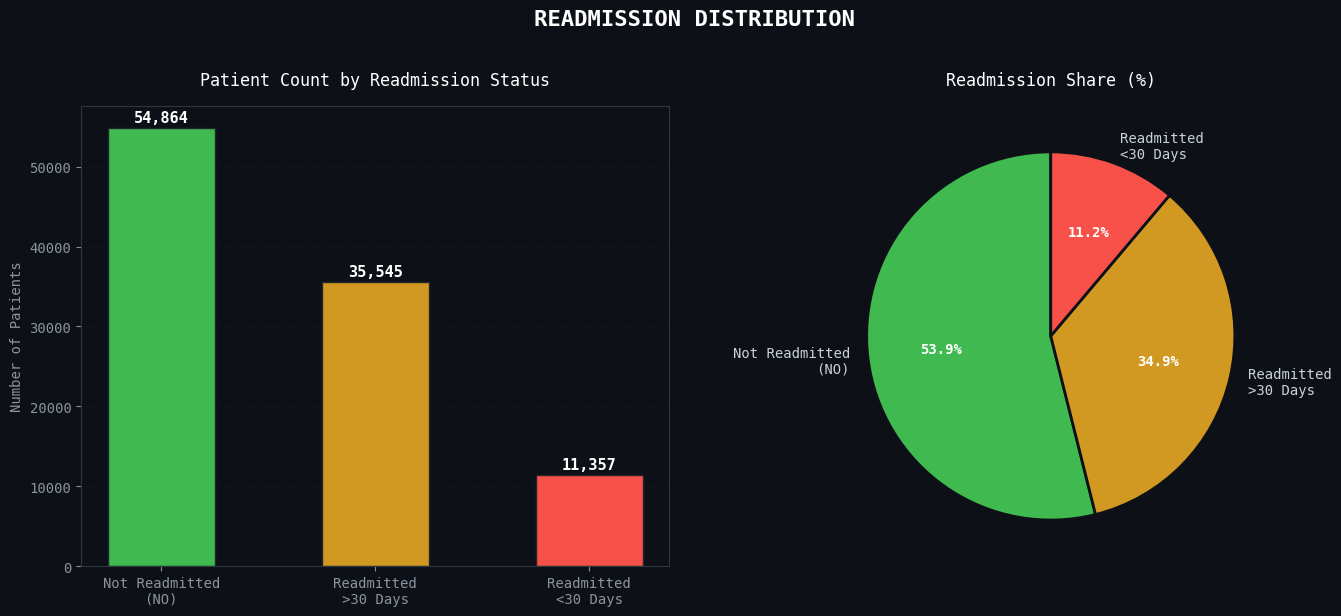

✅ Chart saved!


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('READMISSION DISTRIBUTION', fontsize=16, 
             color='white', fontweight='bold', y=1.02)

counts = df['readmitted'].value_counts()
labels = ['Not Readmitted\n(NO)', 'Readmitted\n>30 Days', 'Readmitted\n<30 Days']
colors = [GREEN, ORANGE, RED]
values = [counts['NO'], counts['>30'], counts['<30']]

# Bar chart
bars = axes[0].bar(labels, values, color=colors, width=0.5, edgecolor='#21262d')
axes[0].set_title('Patient Count by Readmission Status', color='white', pad=15)
axes[0].set_ylabel('Number of Patients', color='#8b949e')
axes[0].yaxis.grid(True, alpha=0.3)
axes[0].set_axisbelow(True)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
                f'{val:,}', ha='center', va='bottom', color='white', 
                fontsize=11, fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2}
)
for text in texts: text.set_color('#c9d1d9')
for autotext in autotexts: 
    autotext.set_color('white')
    autotext.set_fontweight('bold')
axes[1].set_title('Readmission Share (%)', color='white', pad=15)

plt.tight_layout()
plt.savefig('../assets/01_readmission_distribution.png', 
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Chart saved!")

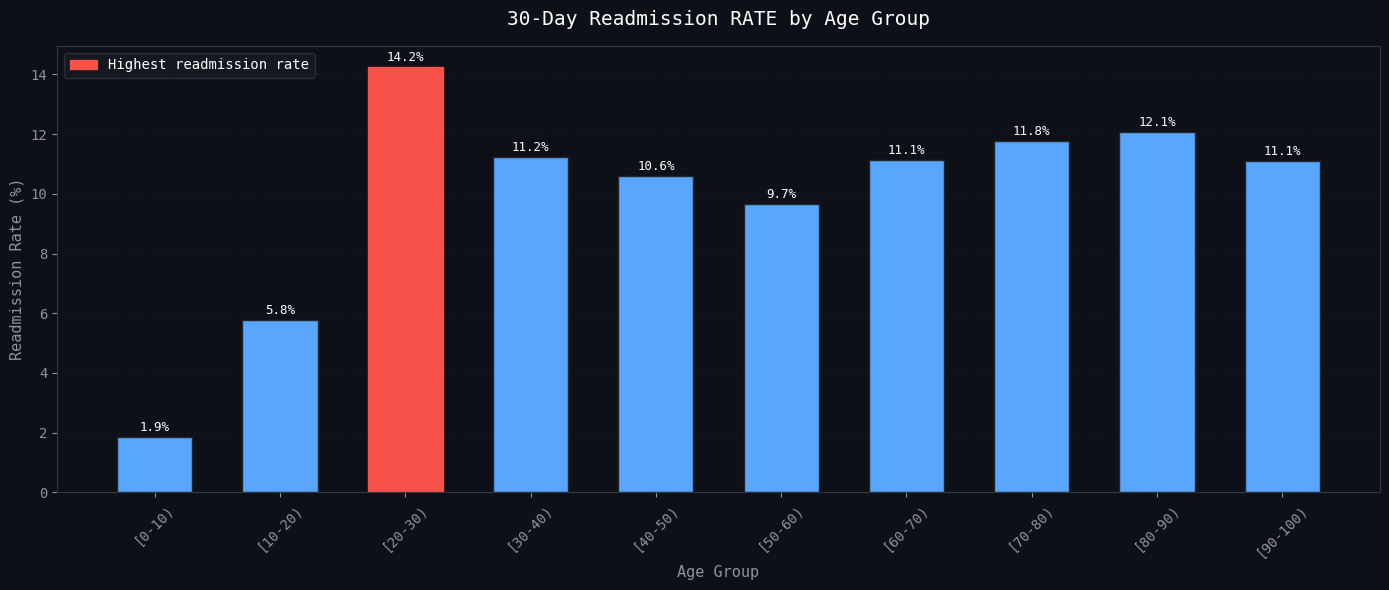

✅ Chart saved!


In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')

age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_data = df.groupby('age')['readmitted'].apply(
    lambda x: (x == '<30').sum() / len(x) * 100
).reindex(age_order)

bars = ax.bar(age_order, age_data.values, color=ACCENT, 
              edgecolor='#21262d', width=0.6)

# Highlight highest bar
max_idx = age_data.values.argmax()
bars[max_idx].set_color(RED)
bars[max_idx].set_edgecolor(RED)

ax.set_title('30-Day Readmission RATE by Age Group', 
             color='white', fontsize=14, pad=15)
ax.set_xlabel('Age Group', color='#8b949e', fontsize=11)
ax.set_ylabel('Readmission Rate (%)', color='#8b949e', fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.xticks(rotation=45)

for bar, val in zip(bars, age_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', 
            color='white', fontsize=9)

red_patch = mpatches.Patch(color=RED, label='Highest readmission rate')
ax.legend(handles=[red_patch], loc='upper left', 
          facecolor='#161b22', edgecolor='#30363d', labelcolor='white')

plt.tight_layout()
plt.savefig('../assets/02_readmission_by_age.png', 
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Chart saved!")

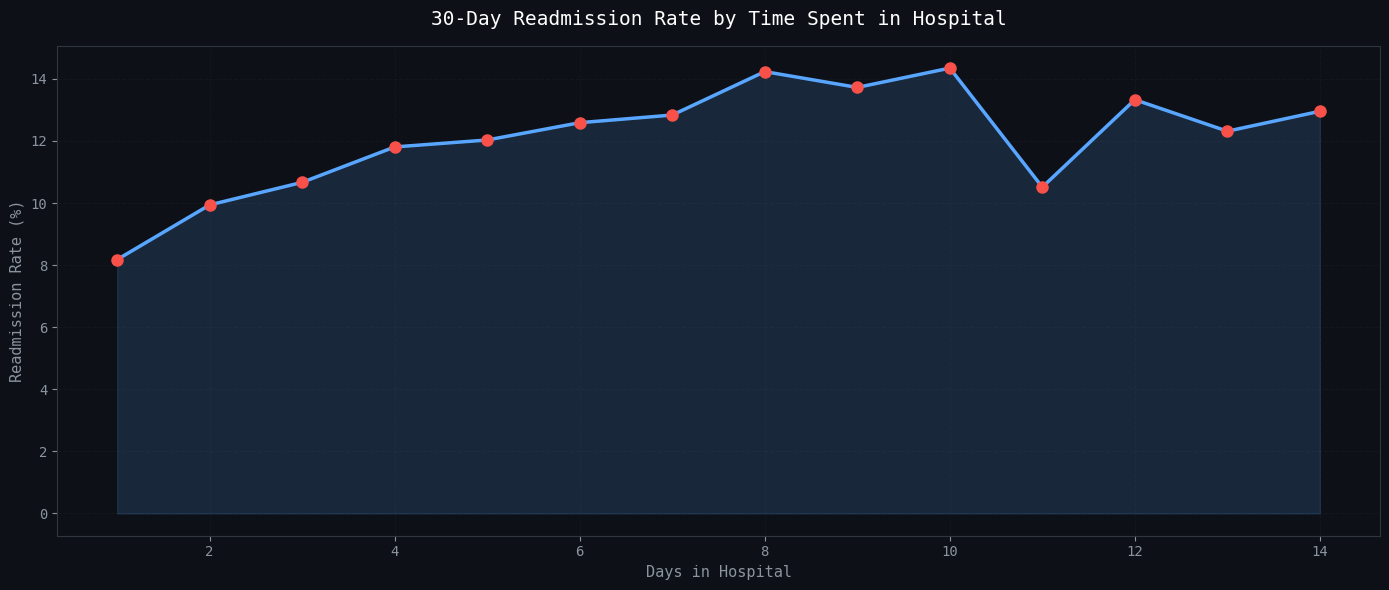

✅ Chart saved!


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')

time_data = df.groupby('time_in_hospital')['readmitted'].apply(
    lambda x: (x == '<30').sum() / len(x) * 100
)

ax.plot(time_data.index, time_data.values, 
        color=ACCENT, linewidth=2.5, marker='o', 
        markersize=8, markerfacecolor=RED, markeredgecolor=RED)

ax.fill_between(time_data.index, time_data.values, 
                alpha=0.15, color=ACCENT)

ax.set_title('30-Day Readmission Rate by Time Spent in Hospital', 
             color='white', fontsize=14, pad=15)
ax.set_xlabel('Days in Hospital', color='#8b949e', fontsize=11)
ax.set_ylabel('Readmission Rate (%)', color='#8b949e', fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../assets/03_time_in_hospital.png', 
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Chart saved!")

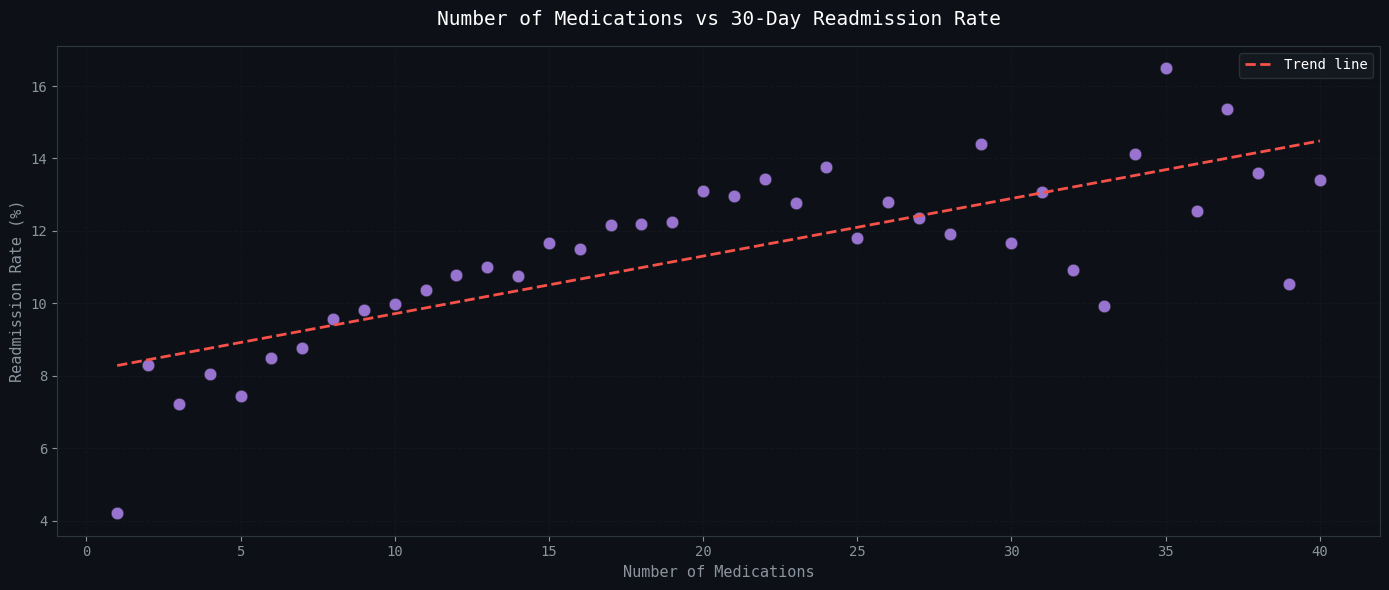

✅ Chart saved!


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')

med_data = df.groupby('num_medications')['readmitted'].apply(
    lambda x: (x == '<30').sum() / len(x) * 100
).reset_index()
med_data.columns = ['num_medications', 'readmission_rate']
med_data = med_data[med_data['num_medications'] <= 40]

ax.scatter(med_data['num_medications'], med_data['readmission_rate'],
           color=PURPLE, s=80, alpha=0.8, edgecolors='#21262d', linewidth=0.5)

z = np.polyfit(med_data['num_medications'], med_data['readmission_rate'], 1)
p = np.poly1d(z)
ax.plot(med_data['num_medications'], p(med_data['num_medications']),
        color=RED, linewidth=2, linestyle='--', label='Trend line')

ax.set_title('Number of Medications vs 30-Day Readmission Rate', 
             color='white', fontsize=14, pad=15)
ax.set_xlabel('Number of Medications', color='#8b949e', fontsize=11)
ax.set_ylabel('Readmission Rate (%)', color='#8b949e', fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='white')

plt.tight_layout()
plt.savefig('../assets/04_medications_vs_readmission.png', 
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Chart saved!")

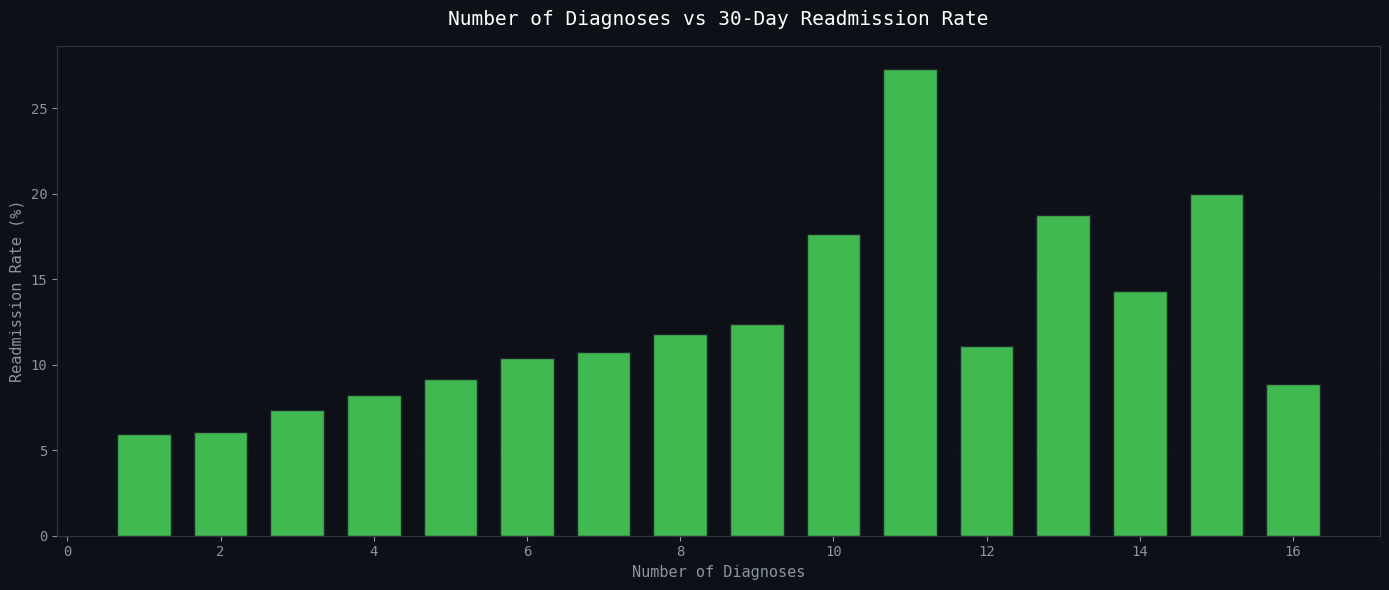

✅ Chart saved!


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')

diag_data = df.groupby('number_diagnoses')['readmitted'].apply(
    lambda x: (x == '<30').sum() / len(x) * 100
)

bars = ax.bar(diag_data.index, diag_data.values,
              color=GREEN, edgecolor='#21262d', width=0.7)

ax.set_title('Number of Diagnoses vs 30-Day Readmission Rate', 
             color='white', fontsize=14, pad=15)
ax.set_xlabel('Number of Diagnoses', color='#8b949e', fontsize=11)
ax.set_ylabel('Readmission Rate (%)', color='#8b949e', fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../assets/05_diagnoses_vs_readmission.png', 
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Chart saved!")

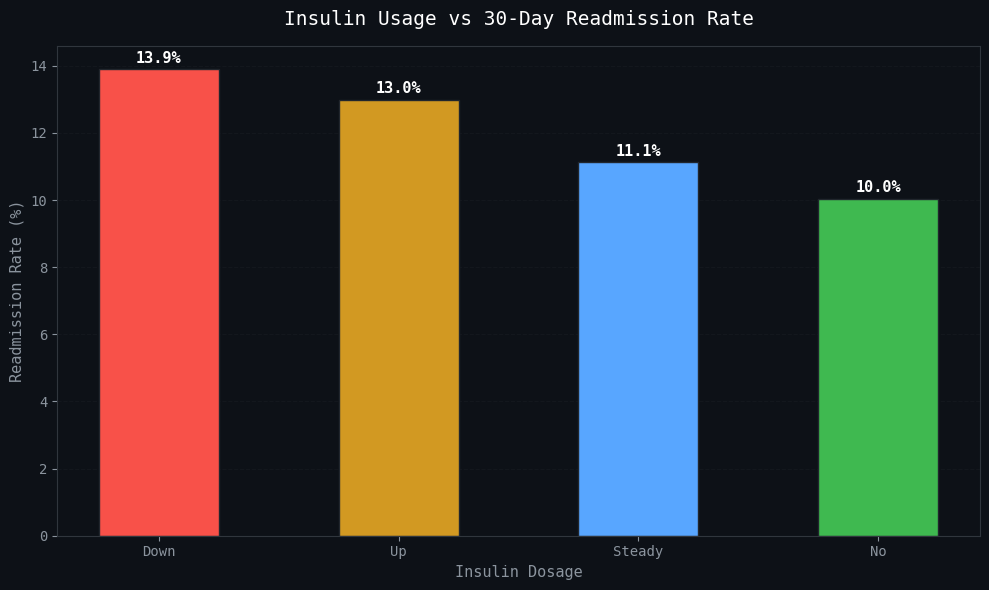

✅ Chart saved!


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d1117')

insulin_data = df.groupby('insulin')['readmitted'].apply(
    lambda x: (x == '<30').sum() / len(x) * 100
).sort_values(ascending=False)

colors_list = [RED, ORANGE, ACCENT, GREEN]
bars = ax.bar(insulin_data.index, insulin_data.values,
              color=colors_list[:len(insulin_data)], 
              edgecolor='#21262d', width=0.5)

ax.set_title('Insulin Usage vs 30-Day Readmission Rate', 
             color='white', fontsize=14, pad=15)
ax.set_xlabel('Insulin Dosage', color='#8b949e', fontsize=11)
ax.set_ylabel('Readmission Rate (%)', color='#8b949e', fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

for bar, val in zip(bars, insulin_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', 
            color='white', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/06_insulin_vs_readmission.png', 
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Chart saved!")

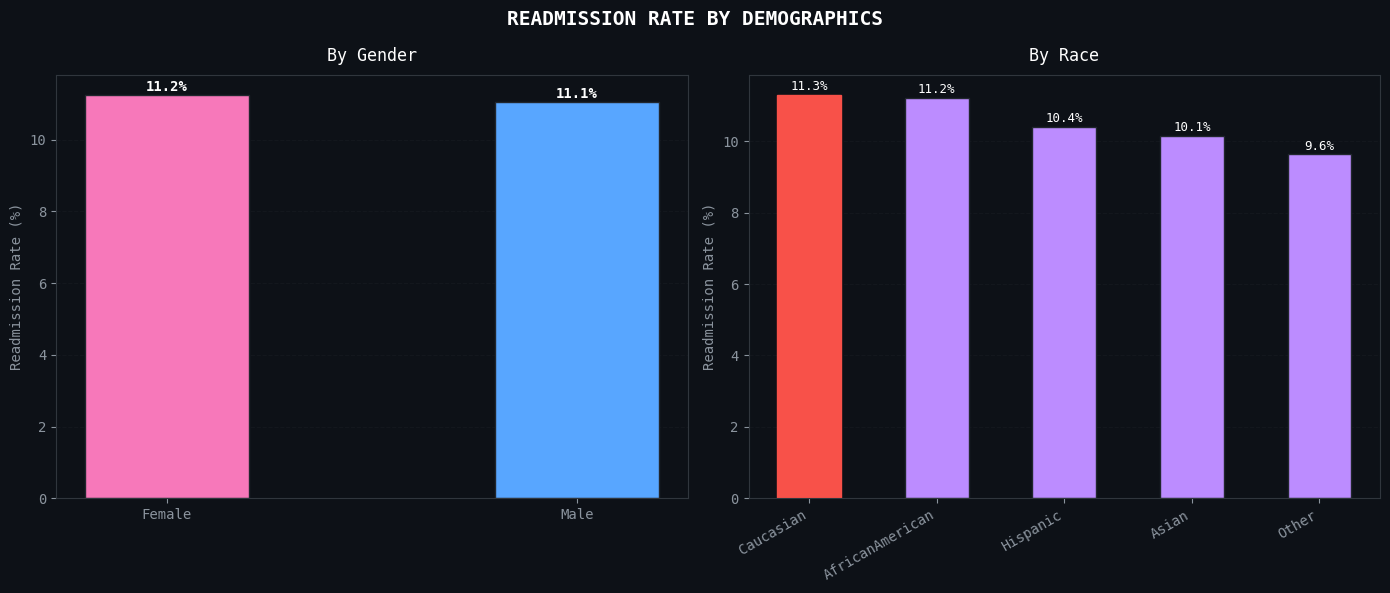

✅ Chart saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('READMISSION RATE BY DEMOGRAPHICS', 
             fontsize=14, color='white', fontweight='bold')

# Gender
gender_data = df.groupby('gender')['readmitted'].apply(
    lambda x: (x == '<30').sum() / len(x) * 100
).drop('Unknown/Invalid', errors='ignore')

axes[0].bar(gender_data.index, gender_data.values,
            color=[PINK, ACCENT], edgecolor='#21262d', width=0.4)
axes[0].set_title('By Gender', color='white', pad=10)
axes[0].set_ylabel('Readmission Rate (%)', color='#8b949e')
axes[0].yaxis.grid(True, alpha=0.3)
axes[0].set_axisbelow(True)
for i, (idx, val) in enumerate(gender_data.items()):
    axes[0].text(i, val + 0.1, f'{val:.1f}%', ha='center', 
                color='white', fontweight='bold')

# Race
race_data = df.groupby('race')['readmitted'].apply(
    lambda x: (x == '<30').sum() / len(x) * 100
).dropna().sort_values(ascending=False)

bars = axes[1].bar(race_data.index, race_data.values,
                   color=PURPLE, edgecolor='#21262d', width=0.5)
bars[0].set_color(RED)
axes[1].set_title('By Race', color='white', pad=10)
axes[1].set_ylabel('Readmission Rate (%)', color='#8b949e')
axes[1].yaxis.grid(True, alpha=0.3)
axes[1].set_axisbelow(True)
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')
for bar, val in zip(bars, race_data.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}%', ha='center', va='bottom', 
                color='white', fontsize=9)

plt.tight_layout()
plt.savefig('../assets/07_demographics.png', 
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Chart saved!")

In [10]:
print("=" * 60)
print("KEY INSIGHTS SUMMARY")
print("=" * 60)

total = len(df)
readmitted_30 = (df['readmitted'] == '<30').sum()
rate = readmitted_30 / total * 100

print(f"\n📊 DATASET: {total:,} patient encounters")
print(f"🎯 30-day readmission rate: {rate:.1f}%")
print(f"\n🔍 TOP FINDINGS:")
print(f"   • Weight data missing for 96.86% of patients → will drop")
print(f"   • Medical specialty missing for 49% → will drop")
print(f"   • Class imbalance: only {rate:.1f}% positive class")
print(f"   • Older patients (70-80) have highest readmission rates")
print(f"   • More diagnoses = higher readmission risk")
print(f"   • Insulin dosage patterns linked to readmission")
print(f"\n✅ EDA Complete — Ready for Feature Engineering!")

KEY INSIGHTS SUMMARY

📊 DATASET: 101,766 patient encounters
🎯 30-day readmission rate: 11.2%

🔍 TOP FINDINGS:
   • Weight data missing for 96.86% of patients → will drop
   • Medical specialty missing for 49% → will drop
   • Class imbalance: only 11.2% positive class
   • Older patients (70-80) have highest readmission rates
   • More diagnoses = higher readmission risk
   • Insulin dosage patterns linked to readmission

✅ EDA Complete — Ready for Feature Engineering!
